# AI Numerasi - XGBoost Classifier Training
Notebook ini berisi langkah-langkah untuk melatih model Machine Learning menggunakan XGBoost berdasarkan dataset hasil jawaban siswa.

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight


## 1. Load Dataset

In [14]:
# Membaca dataset
df = pd.read_csv('numeracy_dataset.csv')
display(df.head())

# Melihat distribusi kelas target
print(df['Target_Level'].value_counts())

,student_id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Target_Level
0,STD_0001,1_A,2_C,3_C,4_B,5_A,6_A,7_B,8_B,9_C,10_B,11_B,12_B,NSI
1,STD_0002,1_B,2_C,3_B,4_C,5_C,6_A,7_A,8_C,9_C,10_B,11_A,12_A,Basic
2,STD_0003,1_C,2_A,3_B,4_A,5_B,6_B,7_A,8_B,9_B,10_A,11_B,12_B,Advanced
3,STD_0004,1_B,2_B,3_B,4_C,5_C,6_B,7_B,8_B,9_B,10_B,11_B,12_A,Basic
4,STD_0005,1_C,2_A,3_B,4_C,5_B,6_B,7_B,8_B,9_B,10_A,11_B,12_B,Proficient


Target_Level
Basic         597
NSI           519
Proficient    234
Advanced      150
Name: count, dtype: int64


## 2. Preprocessing Data

In [15]:
# Buang kolom ID karena tidak relevan untuk prediksi
X = df.drop(columns=['student_id', 'Target_Level'])
y = df['Target_Level']

# Karena fitur Q1-Q12 berisi ID opsi (misal: '1_A', '1_B'), 
# kita harus mengubahnya menjadi numerik (One-Hot Encoding)
X_encoded = pd.get_dummies(X)

# Label Encoding untuk Target Y (NSI, Basic, Proficient, Advanced) menjadi angka (0,1,2,3)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping Kelas:", dict(zip(le.classes_, range(len(le.classes_)))))

# Split Data 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

Mapping Kelas: {'Advanced': 0, 'Basic': 1, 'NSI': 2, 'Proficient': 3}


## 3. XGBoost Model Training

In [16]:
# Menghitung bobot untuk mengatasi ketimpangan data (Class Imbalance)
sample_weights = compute_sample_weight(
    class_weight='balanced', 
    y=y_train
)

# Setup XGBoost Classifier dengan hyperparameter standar untuk klasifikasi Tabular ringan
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    learning_rate=0.05,
    max_depth=4,
    n_estimators=150,
    subsample=0.8,
    random_state=42
)

# Proses Training dengan memberikan perhatian ekstra (weight) pada kelas minoritas seperti Advanced
model.fit(X_train, y_train, sample_weight=sample_weights)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 4. Evaluasi Model

Akurasi: 0.8266666666666667

Laporan Detail:
               precision    recall  f1-score   support

    Advanced       0.66      0.70      0.68        30
       Basic       0.87      0.87      0.87       119
         NSI       0.94      0.88      0.91       104
  Proficient       0.63      0.68      0.65        47

    accuracy                           0.83       300
   macro avg       0.77      0.78      0.78       300
weighted avg       0.83      0.83      0.83       300



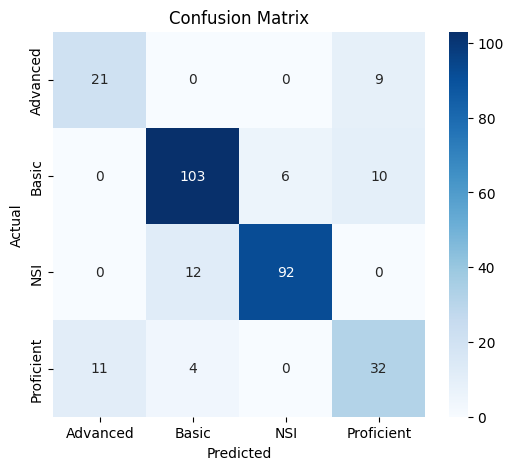

In [17]:
# Lakukan prediksi
y_pred = model.predict(X_test)

# Tampilkan Classification Report
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nLaporan Detail:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## 5. Simpan Model

In [18]:
# Ekspor model ke file JSON agar bisa di-load oleh API / Microservice
model.save_model('xgboost_numerasi.json')
print("Model XGBoost berhasil disimpan sebagai 'xgboost_numerasi.json'")

Model XGBoost berhasil disimpan sebagai 'xgboost_numerasi.json'
